In [123]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

import numpy as np
import matplotlib.pyplot as plt

from src.plot.plot_tools import set_plot_style, plot_seismogram
set_plot_style()

In [124]:
# --- Load binary file from TOYxDAC Time ---
data = np.fromfile("vp_true", dtype=np.float32)
ngrid = 141
medium = data.reshape((ngrid, ngrid))
medium = medium.T
z_coord = np.linspace(0., 700., ngrid)
x_coord = np.linspace(0., 700, ngrid)

seismo_fd = np.fromfile("fsismos_P0000", dtype=np.float32)
nt = 2048
nr = 57
seismo_fd = seismo_fd.reshape((nr, nt))
seismo_fd = seismo_fd.T
time = np.linspace(0, 1.024, nt)
receiver_coord = np.linspace(0., 700., nr)

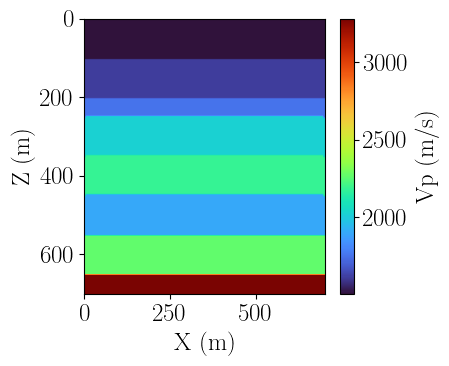

In [125]:
plt.figure(figsize=(4.75, 4))
plt.imshow(
    medium,
    extent=(x_coord.min(), x_coord.max(), 
            z_coord.max(), z_coord.min()),
    aspect='auto',
    cmap='turbo',
)
plt.colorbar(label="Vp (m/s)")
plt.xlabel("X (m)")
plt.ylabel("Z (m)")
plt.tight_layout()
plt.show()

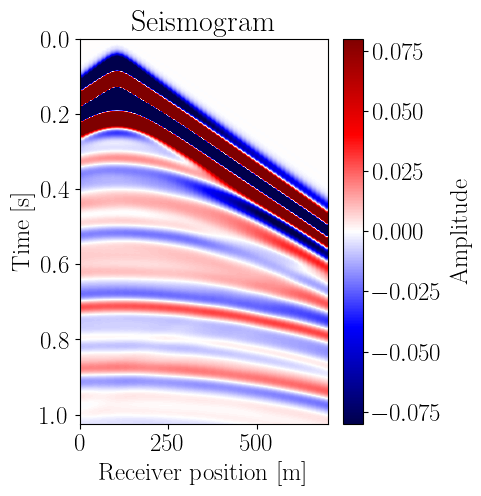

In [126]:
max = np.max(np.abs(seismo_fd))
seismo_fd = seismo_fd / max

plot_seismogram(seismo_fd, receiver_coord, time, vmin=-0.08, vmax=0.08, cmap='seismic', ncolors=256, figsize=(4, 5))

In [127]:
reflectivity = np.loadtxt("d_cal_seis.txt").flatten()
nt_ref = 164
ref = reflectivity.reshape((nr, nt_ref))
ref_normed = ref / np.max(np.abs(ref))
time_ref = np.linspace(0, 1.024, nt_ref)
t0 = 0.6
mask = time > t0


err, errL2 = np.zeros(nr), np.zeros(nr)
for ind in range(nr):
    trace_ref = ref_normed[ind, :]
    # interpolate the reflectivity trace to match time sampling of FD code
    trace_ref_interp = np.interp(time, time_ref, trace_ref)
    dt = time[1] - time[0]
    trace = seismo_fd[:, ind]
    residual = trace_ref_interp - trace
    err[ind] = np.max(np.abs(residual))
    errL2[ind] = np.sqrt(np.sum(residual[mask]**2))

max_recv_err, max_recv_ind = np.max(err), np.argmax(err)
print(f"max absolute error between reflectivity and TOYxDAC seismogram: {max_recv_err}")
print(f"receiver index with max error: {max_recv_ind}")

max_recv_errL2, max_recv_indL2 = np.max(errL2), np.argmax(errL2)
print(f"max L2 error between reflectivity and TOYxDAC seismogram: {max_recv_errL2}")
print(f"receiver index with max L2 error: {max_recv_indL2}")

max absolute error between reflectivity and TOYxDAC seismogram: 0.030635914290300215
receiver index with max error: 8
max L2 error between reflectivity and TOYxDAC seismogram: 0.06409056505564237
receiver index with max L2 error: 54


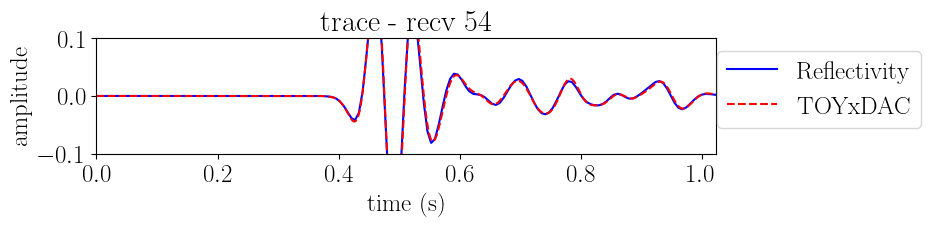

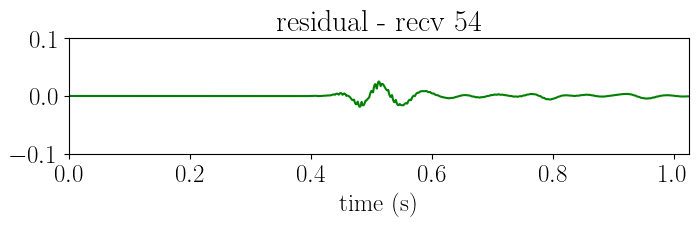

In [128]:
trace_ref = ref_normed[max_recv_indL2, :]
trace_ref_interp = np.interp(time, time_ref, trace_ref)
trace = seismo_fd[:, max_recv_indL2]

plt.figure(figsize=(8, 1.5))
plt.plot(time, trace_ref_interp, 'b-', label='Reflectivity')
plt.plot(time, trace, 'r--', label='TOYxDAC')
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.title(f"trace - recv {max_recv_indL2}")
plt.xlim(0, 1.024)
plt.ylim(-0.1, 0.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.show()

plt.figure(figsize=(8, 1.5))
plt.plot(time, residual, 'g-')
plt.xlabel("time (s)")
plt.title(f"residual - recv {max_recv_indL2}")
plt.xlim(0, 1.024)
plt.ylim(-0.1, 0.1)
plt.show()